<div style="background:linear-gradient(135deg,#0D1B2A 0%,#1565C0 100%);padding:36px 40px;border-radius:12px;margin-bottom:8px;">
  <div style="display:flex;align-items:center;gap:16px;">
    <span style="font-size:48px;">🛰️</span>
    <div>
      <p style="color:#ADE8F4;margin:0;font-size:13px;letter-spacing:3px;text-transform:uppercase;font-family:monospace;">Computer Vision for Remote Sensing · Bangladesh</p>
      <h1 style="color:#FFFFFF;margin:4px 0 0 0;font-size:28px;font-family:monospace;">Phase 1 · Raster CV Foundations</h1>
    </div>
  </div>
  <hr style="border-color:#1E88E5;margin:20px 0 16px 0;"/>
  <div style="display:flex;gap:32px;flex-wrap:wrap;">
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📘 Lesson <b style="color:#FFF">L3 / 7</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">⏱ Est. Time <b style="color:#FFF">3 hrs</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📍 Study Area <b style="color:#FFF">Bhairab (flood)</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📅 Date <b style="color:#FFF">____-__-__</b></span>
  </div>
</div>
<div style="background:#1565C022;border-left:5px solid #1565C0;padding:18px 24px;border-radius:0 8px 8px 0;">
  <h2 style="color:#1565C0;margin:0 0 8px 0;font-size:18px;">📖 L3 — Band Math & Spectral Indices</h2>
  <p style="margin:0;color:#1A2A3A;font-size:14px;">📝 <i>Add lesson description here — what is this lesson about?</i></p>
</div>

## 🎯 Objectives

By the end of this lesson you will be able to:

- ✅ _Objective 1_
- ✅ _Objective 2_
- ✅ _Objective 3_

---

## 🔑 Key Functions

| Function | Purpose |
|---|---|
| `function()` | description |


---
## ⚙️ Setup & Imports

In [14]:
# ── Cell 1: Imports & Paths ────────────────────────────────────────────────
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd
from rasterio.mask import mask as rio_mask
from shapely.geometry import mapping

# ── Band paths ─────────────────────────────────────────────────────────────
BASE = pathlib.Path(r"H:/gis all/Band image cv roadmap geospatial/LC09_L2SP_137043_20260219_20260220_02_T1")

B2_PATH = BASE / "LC09_L2SP_137043_20260219_20260220_02_T1_SR_B2.TIF"
B3_PATH = BASE / "LC09_L2SP_137043_20260219_20260220_02_T1_SR_B3.TIF"
B4_PATH = BASE / "LC09_L2SP_137043_20260219_20260220_02_T1_SR_B4.TIF"
B5_PATH = BASE / "LC09_L2SP_137043_20260219_20260220_02_T1_SR_B5.TIF"
B6_PATH = BASE / "LC09_L2SP_137043_20260219_20260220_02_T1_SR_B6.TIF"
B7_PATH = BASE / "LC09_L2SP_137043_20260219_20260220_02_T1_SR_B7.TIF"

# ── Shapefile & output ─────────────────────────────────────────────────────
SHP_PATH = pathlib.Path(r"H:/gis all/test matuail land/shape file/Jatrabari.shp")
FIG_DIR  = pathlib.Path(r"C:/Users/sahri/Downloads/geospatial-cv-roadmap/outputs/figures/phase1/")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Verify ─────────────────────────────────────────────────────────────────
files = {
    'Shapefile': SHP_PATH,
    'B2 Blue'  : B2_PATH,
    'B3 Green' : B3_PATH,
    'B4 Red'   : B4_PATH,
    'B5 NIR'   : B5_PATH,
    'B6 SWIR1' : B6_PATH,
    'B7 SWIR2' : B7_PATH,
}
print("File check:")
for name, path in files.items():
    print(f"  {'✅' if path.exists() else '❌'} {name}")

File check:
  ✅ Shapefile
  ✅ B2 Blue
  ✅ B3 Green
  ✅ B4 Red
  ✅ B5 NIR
  ✅ B6 SWIR1
  ✅ B7 SWIR2


In [15]:
# ── Cell 2: Load Shapefile & Read Bands with Correct Scaling ──────────────

# ── Load shapefile ─────────────────────────────────────────────────────────
jatrabari = gpd.read_file(SHP_PATH)
print(f"Shapefile loaded:")
print(f"  CRS      : {jatrabari.crs}")
print(f"  Features : {len(jatrabari)}")
print(f"  Bounds   : {jatrabari.total_bounds}")

# ── Read & crop function with correct C2 L2 scale ─────────────────────────
def read_crop_band(path, shapes):
    """
    Read band cropped to shapefile boundary.
    Landsat Collection 2 L2 scale: DN × 0.0000275 + (-0.2)
    """
    with rasterio.open(path) as src:
        # Reproject shapefile to raster CRS
        shapes_reproj = shapes.to_crs(src.crs)
        geoms = [mapping(geom) for geom in shapes_reproj.geometry]

        # Crop to boundary
        band, transform = rio_mask(src, geoms, crop=True, nodata=0)
        band = band[0].astype('float32')

        profile = src.profile.copy()
        profile.update({
            'height'   : band.shape[0],
            'width'    : band.shape[1],
            'transform': transform,
            'dtype'    : 'float32',
            'nodata'   : np.nan,
        })

    # Mask nodata zeros
    band = np.where(band == 0, np.nan, band)

    # Correct Landsat C2 L2 scale formula
    band = band * 0.0000275 + (-0.2)

    # Clip to valid reflectance [0, 1]
    band = np.clip(band, 0, 1)
    return band, profile

# ── Read all bands ─────────────────────────────────────────────────────────
print("\nReading & cropping bands to Jatrabari...")
blue,  _       = read_crop_band(B2_PATH, jatrabari)
green, _       = read_crop_band(B3_PATH, jatrabari)
red,   _       = read_crop_band(B4_PATH, jatrabari)
nir,   profile = read_crop_band(B5_PATH, jatrabari)
swir1, _       = read_crop_band(B6_PATH, jatrabari)
swir2, _       = read_crop_band(B7_PATH, jatrabari)

print(f"\n  ✅ All bands loaded!")
print(f"  Shape : {nir.shape}")
print(f"\n  Reflectance ranges:")
print(f"    Blue  : {np.nanmin(blue):.4f} – {np.nanmax(blue):.4f}  mean={np.nanmean(blue):.4f}")
print(f"    Green : {np.nanmin(green):.4f} – {np.nanmax(green):.4f}  mean={np.nanmean(green):.4f}")
print(f"    Red   : {np.nanmin(red):.4f} – {np.nanmax(red):.4f}  mean={np.nanmean(red):.4f}")
print(f"    NIR   : {np.nanmin(nir):.4f} – {np.nanmax(nir):.4f}  mean={np.nanmean(nir):.4f}")
print(f"    SWIR1 : {np.nanmin(swir1):.4f} – {np.nanmax(swir1):.4f}  mean={np.nanmean(swir1):.4f}")
print(f"    SWIR2 : {np.nanmin(swir2):.4f} – {np.nanmax(swir2):.4f}  mean={np.nanmean(swir2):.4f}")

Shapefile loaded:
  CRS      : EPSG:4326
  Features : 2
  Bounds   : [90.42314443 23.69484426 90.47642843 23.73319181]

Reading & cropping bands to Jatrabari...

  ✅ All bands loaded!
  Shape : (143, 182)

  Reflectance ranges:
    Blue  : 0.0243 – 0.1564  mean=0.0723
    Green : 0.0447 – 0.1939  mean=0.0927
    Red   : 0.0368 – 0.2250  mean=0.0997
    NIR   : 0.0427 – 0.4766  mean=0.1659
    SWIR1 : 0.0147 – 0.3912  mean=0.1643
    SWIR2 : 0.0108 – 1.0000  mean=0.1407


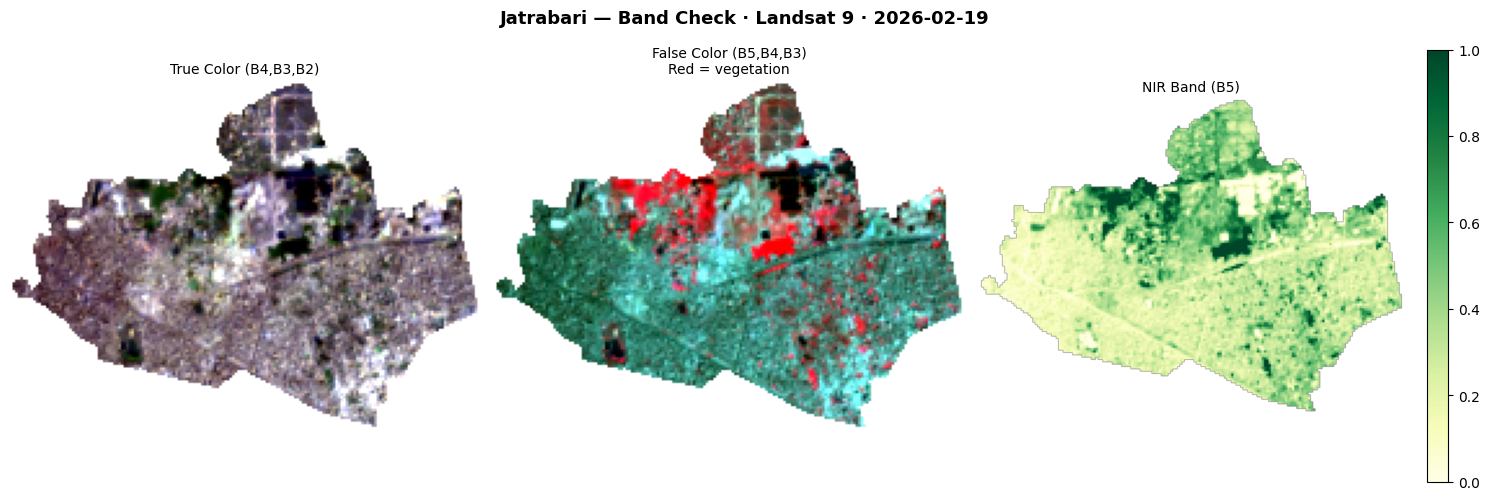

✓ Saved → L3_band_check.png


In [16]:
# ── Cell 3: Visual Check ───────────────────────────────────────────────────
def display(band, lo_pct=2, hi_pct=98):
    lo = np.nanpercentile(band, lo_pct)
    hi = np.nanpercentile(band, hi_pct)
    return np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Jatrabari — Band Check · Landsat 9 · 2026-02-19',
             fontsize=13, fontweight='bold')

# True color RGB
rgb = np.stack([display(red), display(green), display(blue)], axis=-1)
rgb[np.isnan(red)] = 1.0
axes[0].imshow(rgb)
axes[0].set_title('True Color (B4,B3,B2)', fontsize=10)
axes[0].axis('off')

# False color (NIR, Red, Green)
fcc = np.stack([display(nir), display(red), display(green)], axis=-1)
fcc[np.isnan(nir)] = 1.0
axes[1].imshow(fcc)
axes[1].set_title('False Color (B5,B4,B3)\nRed = vegetation', fontsize=10)
axes[1].axis('off')

# NIR band
im = axes[2].imshow(display(nir), cmap='YlGn')
plt.colorbar(im, ax=axes[2], fraction=0.046)
axes[2].set_title('NIR Band (B5)', fontsize=10)
axes[2].axis('off')

plt.tight_layout()
plt.savefig(FIG_DIR / 'L3_band_check.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved → L3_band_check.png")

In [17]:
# ── Cell 4: Safe Divide & Compute All Indices ─────────────────────────────
def safe_divide(a, b):
    return np.where(
        (b == 0) | np.isnan(b) | np.isnan(a),
        np.nan, a / b
    )

# Compute indices
NDVI  = np.clip(safe_divide(nir - red,    nir + red),    -1, 1)
NDWI  = np.clip(safe_divide(green - nir,  green + nir),  -1, 1)
MNDWI = np.clip(safe_divide(green - swir1, green + swir1),-1, 1)
NDBI  = np.clip(safe_divide(swir1 - nir,  swir1 + nir),  -1, 1)
NBR   = np.clip(safe_divide(nir - swir2,  nir + swir2),  -1, 1)

print("=" * 52)
print("  SPECTRAL INDICES — Jatrabari Feb 2026")
print("=" * 52)
indices = {
    'NDVI  (vegetation)': NDVI,
    'NDWI  (water)     ': NDWI,
    'MNDWI (mod. water)': MNDWI,
    'NDBI  (built-up)  ': NDBI,
    'NBR   (burn ratio)': NBR,
}
for name, idx in indices.items():
    print(f"  {name}: "
          f"min={np.nanmin(idx):.3f}  "
          f"max={np.nanmax(idx):.3f}  "
          f"mean={np.nanmean(idx):.3f}")

  SPECTRAL INDICES — Jatrabari Feb 2026
  NDVI  (vegetation): min=-0.115  max=0.853  mean=0.232
  NDWI  (water)     : min=-0.775  max=0.201  mean=-0.264
  MNDWI (mod. water): min=-0.581  max=0.595  mean=-0.262
  NDBI  (built-up)  : min=-0.574  max=0.312  mean=-0.005
  NBR   (burn ratio): min=-0.672  max=0.775  mean=0.085


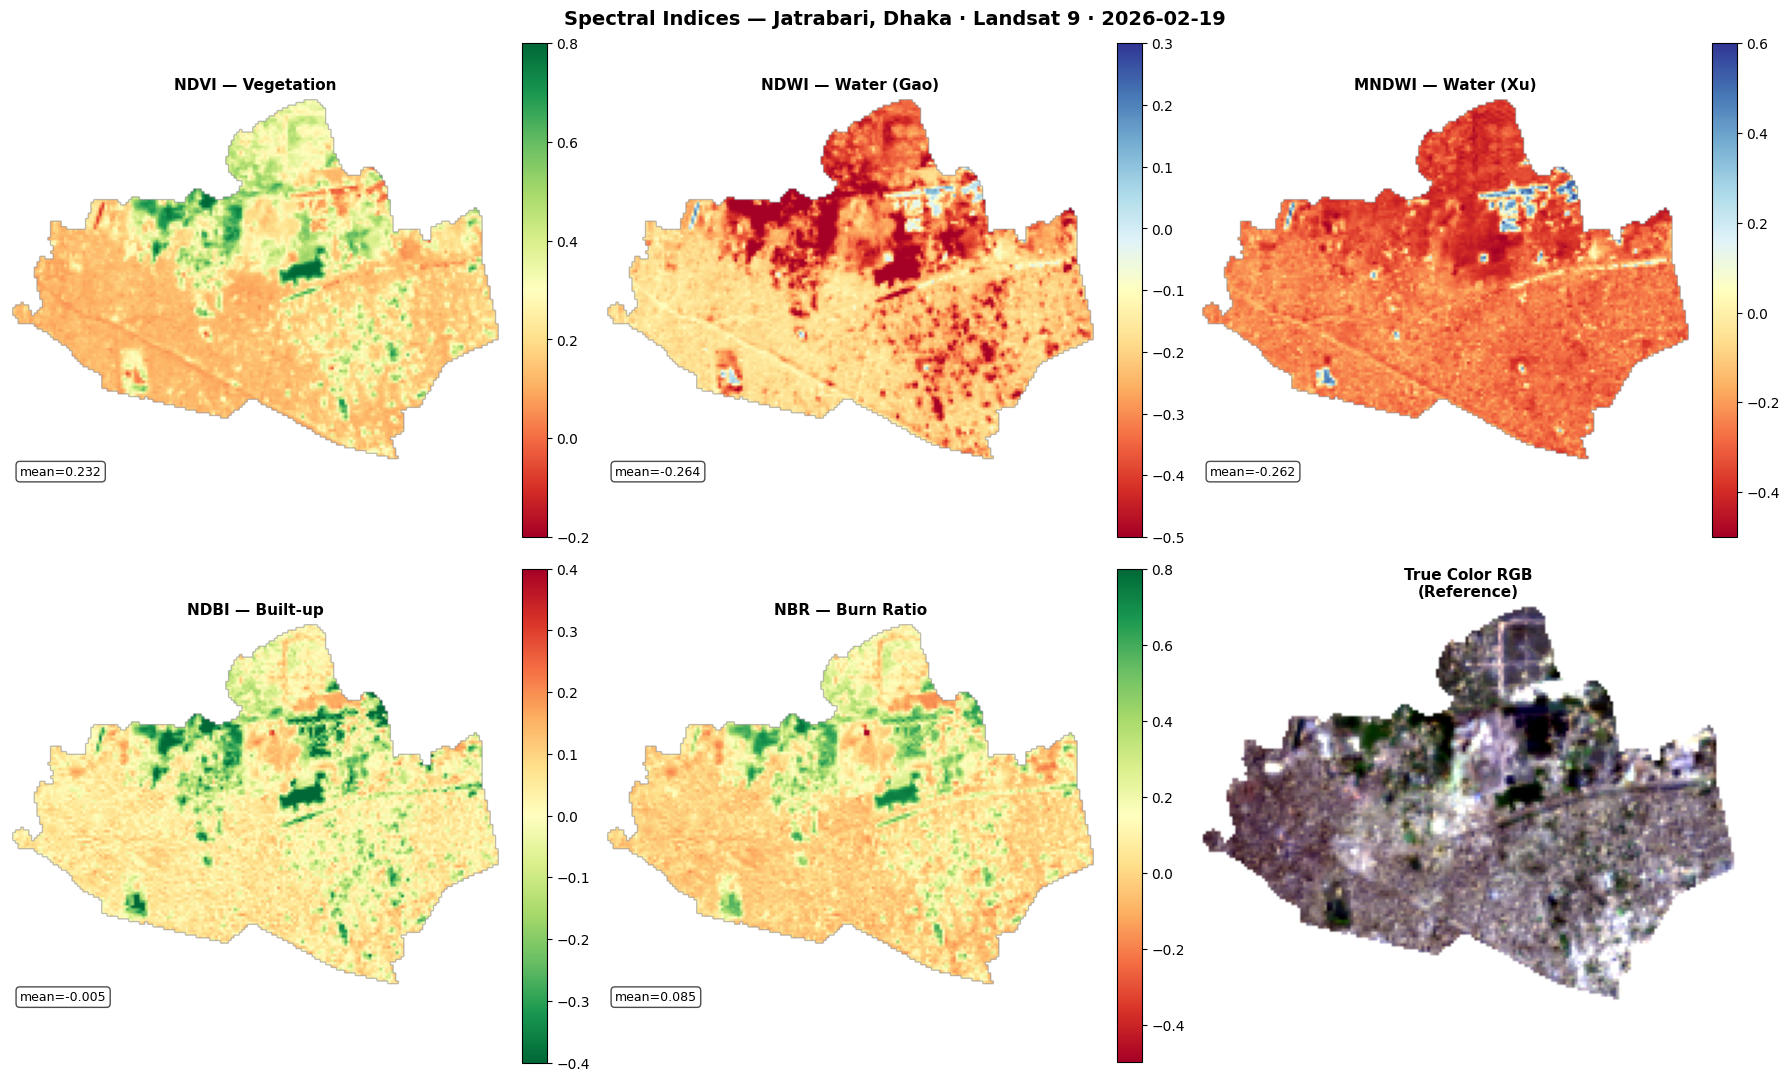

✓ Saved → outputs/figures/phase1/L3_spectral_indices.png


In [18]:
# ── Cell 5: Visualize All Indices ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Spectral Indices — Jatrabari, Dhaka · Landsat 9 · 2026-02-19',
             fontsize=14, fontweight='bold')

indices_plot = [
    (NDVI,  'NDVI — Vegetation',          'RdYlGn',  -0.2, 0.8),
    (NDWI,  'NDWI — Water (Gao)',         'RdYlBu',  -0.5, 0.3),
    (MNDWI, 'MNDWI — Water (Xu)',         'RdYlBu',  -0.5, 0.6),
    (NDBI,  'NDBI — Built-up',            'RdYlGn_r',-0.4, 0.4),
    (NBR,   'NBR — Burn Ratio',           'RdYlGn',  -0.5, 0.8),
]

for i, (idx, title, cmap, vmin, vmax) in enumerate(indices_plot):
    row, col = divmod(i, 3)
    im = axes[row, col].imshow(idx, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=axes[row, col], fraction=0.046, pad=0.04)
    axes[row, col].set_title(title, fontsize=11, fontweight='bold')
    axes[row, col].axis('off')
    # Add mean value as text
    axes[row, col].text(0.02, 0.02,
                        f'mean={np.nanmean(idx):.3f}',
                        transform=axes[row, col].transAxes,
                        fontsize=9, color='black',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Last panel — RGB for reference
rgb = np.stack([display(red), display(green), display(blue)], axis=-1)
rgb[np.isnan(red)] = 1.0
axes[1, 2].imshow(rgb)
axes[1, 2].set_title('True Color RGB\n(Reference)', fontsize=11, fontweight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(FIG_DIR / 'L3_spectral_indices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved → outputs/figures/phase1/L3_spectral_indices.png")

  LAND COVER — Jatrabari Feb 2026
  Water      :      245 px  (1.8%)
  Vegetation :    5,839 px  (43.8%)
  Built-up   :    7,109 px  (53.3%)
  Bare soil  :      612 px  (4.6%)
  Total      :   13,342 px


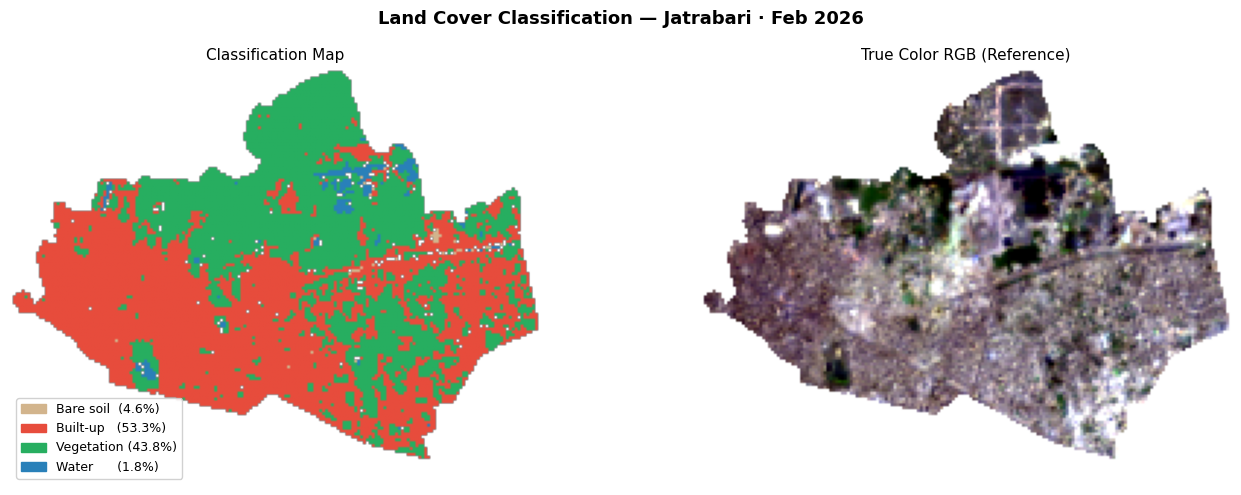

✓ Saved → L3_classification.png


In [19]:
# ── Cell 6: Classification with correct thresholds ────────────────────────
# Thresholds for urban Bangladesh dry season
water_mask = MNDWI > 0.1          # water
veg_mask   = NDVI  > 0.2          # vegetation  
urban_mask = (NDBI > -0.05) & ~water_mask & ~veg_mask  # built-up
bare_mask  = (NDVI < 0.1)  & ~water_mask               # bare soil

total = np.sum(~np.isnan(NDVI))

print("=" * 52)
print("  LAND COVER — Jatrabari Feb 2026")
print("=" * 52)
print(f"  Water      : {np.nansum(water_mask):>8,} px  ({np.nansum(water_mask)/total*100:.1f}%)")
print(f"  Vegetation : {np.nansum(veg_mask):>8,} px  ({np.nansum(veg_mask)/total*100:.1f}%)")
print(f"  Built-up   : {np.nansum(urban_mask):>8,} px  ({np.nansum(urban_mask)/total*100:.1f}%)")
print(f"  Bare soil  : {np.nansum(bare_mask):>8,} px  ({np.nansum(bare_mask)/total*100:.1f}%)")
print(f"  Total      : {total:>8,} px")

# ── Visualize classification map ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Land Cover Classification — Jatrabari · Feb 2026',
             fontsize=13, fontweight='bold')

# Classification map
class_map = np.full(NDVI.shape, np.nan)
class_map[bare_mask]  = 1   # bare soil
class_map[urban_mask] = 2   # built-up
class_map[veg_mask]   = 3   # vegetation
class_map[water_mask] = 4   # water

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
cmap = ListedColormap(['#D2B48C', '#E74C3C', '#27AE60', '#2980B9'])

im = axes[0].imshow(class_map, cmap=cmap, vmin=1, vmax=4)
axes[0].set_title('Classification Map', fontsize=11)
axes[0].axis('off')
legend = [
    Patch(color='#D2B48C', label=f'Bare soil  ({np.nansum(bare_mask)/total*100:.1f}%)'),
    Patch(color='#E74C3C', label=f'Built-up   ({np.nansum(urban_mask)/total*100:.1f}%)'),
    Patch(color='#27AE60', label=f'Vegetation ({np.nansum(veg_mask)/total*100:.1f}%)'),
    Patch(color='#2980B9', label=f'Water      ({np.nansum(water_mask)/total*100:.1f}%)'),
]
axes[0].legend(handles=legend, loc='lower left', fontsize=9,
               framealpha=0.9)

# RGB reference
rgb = np.stack([display(red), display(green), display(blue)], axis=-1)
rgb[np.isnan(red)] = 1.0
axes[1].imshow(rgb)
axes[1].set_title('True Color RGB (Reference)', fontsize=11)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(FIG_DIR / 'L3_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved → L3_classification.png")

In [20]:
# ── Cell 7: Save All Indices as GeoTIFF ───────────────────────────────────
OUT_DIR = pathlib.Path(r"C:/Users/sahri/Downloads/geospatial-cv-roadmap/outputs/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Output profile — single band float32
out_profile = profile.copy()
out_profile.update({'dtype': 'float32', 'count': 1, 'nodata': np.nan})

indices_save = {
    'NDVI' : NDVI,
    'NDWI' : NDWI,
    'MNDWI': MNDWI,
    'NDBI' : NDBI,
    'NBR'  : NBR,
}

for name, idx in indices_save.items():
    out_path = OUT_DIR / f"Jatrabari_{name}_2026Feb.tif"
    with rasterio.open(out_path, 'w', **out_profile) as dst:
        dst.write(idx.astype('float32'), 1)
    print(f"  ✓ Saved → {out_path.name}")

print(f"\nAll indices saved → {OUT_DIR}")
print("Open in QGIS to verify georeferencing ✅")

  ✓ Saved → Jatrabari_NDVI_2026Feb.tif
  ✓ Saved → Jatrabari_NDWI_2026Feb.tif
  ✓ Saved → Jatrabari_MNDWI_2026Feb.tif
  ✓ Saved → Jatrabari_NDBI_2026Feb.tif
  ✓ Saved → Jatrabari_NBR_2026Feb.tif

All indices saved → C:\Users\sahri\Downloads\geospatial-cv-roadmap\outputs
Open in QGIS to verify georeferencing ✅


---
## 📝 My Notes

> _Fill in after completing the exercise._

- Observation 1: `____`
- Observation 2: `____`
- Anything unexpected: `____`


---
<div style="background:linear-gradient(135deg,#0D1B2A 0%,#1565C0 100%);padding:24px 32px;border-radius:10px;">
  <h2 style="color:#FFFFFF;margin:0 0 12px 0;font-size:18px;">✅ Key Takeaways — L3</h2>
  <ul style="color:#C8E6C9;font-size:14px;line-height:2.2;margin:0;">
    <li>_Takeaway 1_</li>
    <li>_Takeaway 2_</li>
    <li>_Takeaway 3_</li>
  </ul>
</div>

---
<div style="display:flex;justify-content:space-between;padding:10px 0;font-size:13px;color:#9E9E9E;">
  <span>← Previous: <a href="L2_prev.ipynb">L2</a></span>
  <b style="color:#1565C0;">Phase 1 · L3 of 7</b>
  <span><a href="L4_next.ipynb" style="color:#1565C0;">Next: L4 →</a></span>
</div>